Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error
from qiskit.visualization import plot_histogram

Build a Simple Circuit

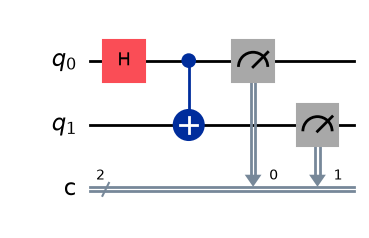

In [2]:
qc_short = QuantumCircuit(2, 2)
qc_short.h(0)
qc_short.cx(0, 1)
qc_short.measure([0, 1], [0, 1])

qc_short.draw('mpl')

Run Without Noise (Ideal Simulation)

Ideal counts: {'00': 519, '11': 505}


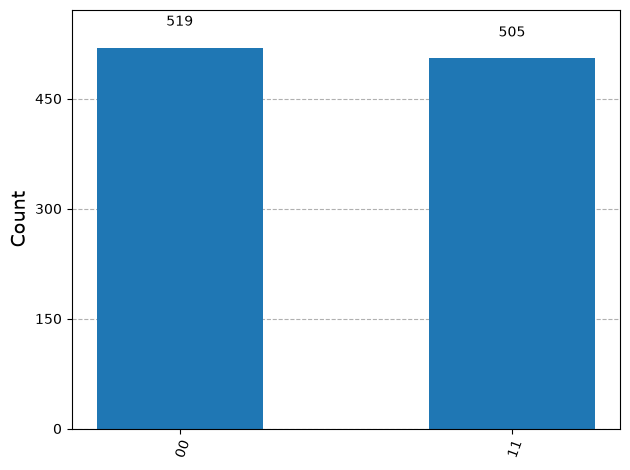

In [3]:
simulator = AerSimulator()
compiled_short = transpile(qc_short, simulator)
result_ideal = simulator.run(compiled_short, shots=1024).result()
counts_ideal = result_ideal.get_counts()

print("Ideal counts:", counts_ideal)
plot_histogram(counts_ideal)

Create a Noise Model with T1 and T2

In [4]:
t1 = 50e-6    # 50 microseconds
t2 = 30e-6    # 30 microseconds (dephasing limited)
gate_time_1q = 50e-9   # 50 nanoseconds for single-qubit gates
gate_time_2q = 500e-9  # 500 nanoseconds for two-qubit gates

noise_model = NoiseModel()

# Single-qubit error
error_1q = thermal_relaxation_error(t1, t2, gate_time_1q)

# 2-qubit error (created by tensoring two single-qubit errors together)
error_2q_single = thermal_relaxation_error(t1, t2, gate_time_2q)
error_2q = error_2q_single.tensor(error_2q_single)

noise_model.add_all_qubit_quantum_error(error_1q, ['h'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

Run the Short Circuit With Noise

Noisy counts (short circuit): {'01': 8, '11': 497, '10': 7, '00': 512}


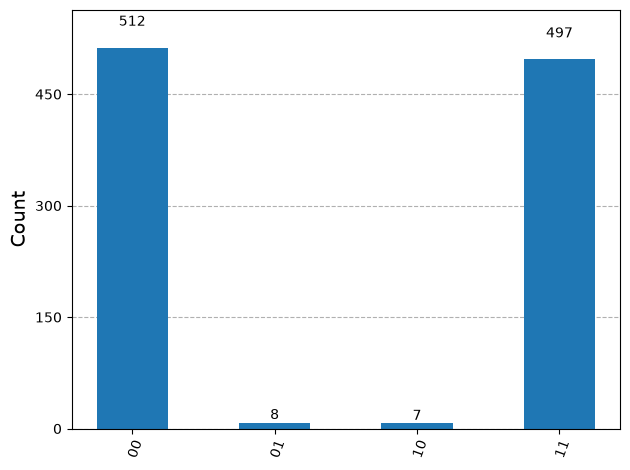

In [5]:
noisy_simulator = AerSimulator(noise_model=noise_model)
compiled_noisy = transpile(qc_short, noisy_simulator)
result_noisy = noisy_simulator.run(compiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

print("Noisy counts (short circuit):", counts_noisy)
plot_histogram(counts_noisy)

Build a Long Circuit

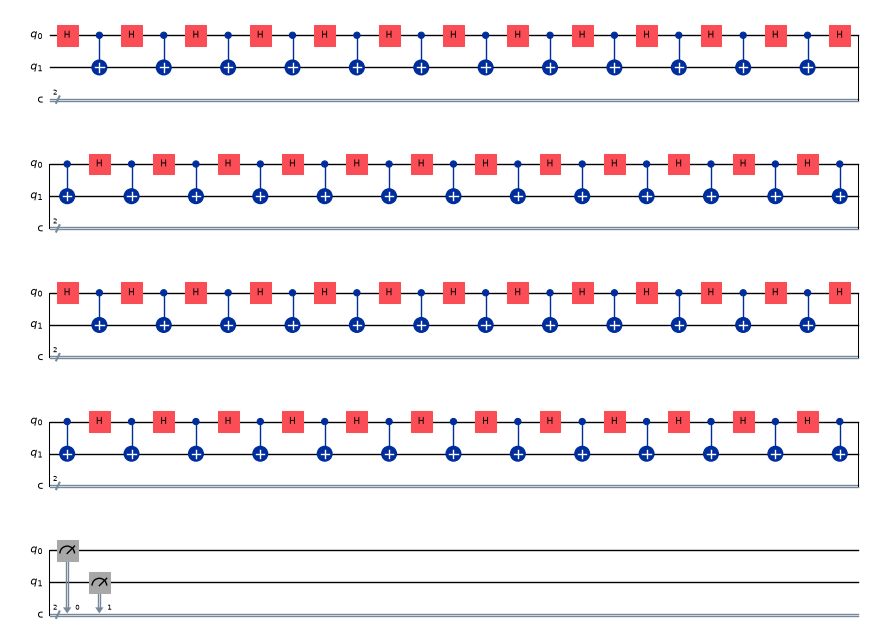

In [6]:
qc_long = QuantumCircuit(2, 2)
for _ in range(50):
    qc_long.h(0)
    qc_long.cx(0, 1)
qc_long.measure([0, 1], [0, 1])

qc_long.draw('mpl', scale=0.5)

Noisy counts (long circuit): {'11': 250, '10': 259, '00': 276, '01': 239}


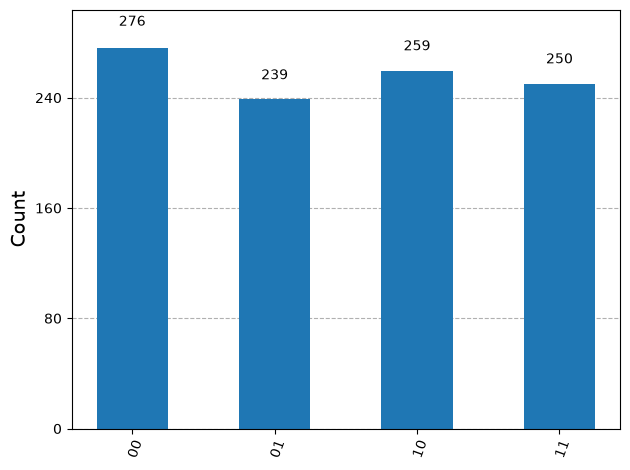

In [9]:
transpiled_circuit_long = transpile(qc_long, simulator)
job_long = simulator.run(transpiled_circuit_long, shots=1024)
counts_long = job_long.result().get_counts()

print("Noisy counts (long circuit):", counts_long)
plot_histogram(counts_long)

Compare Side by Side

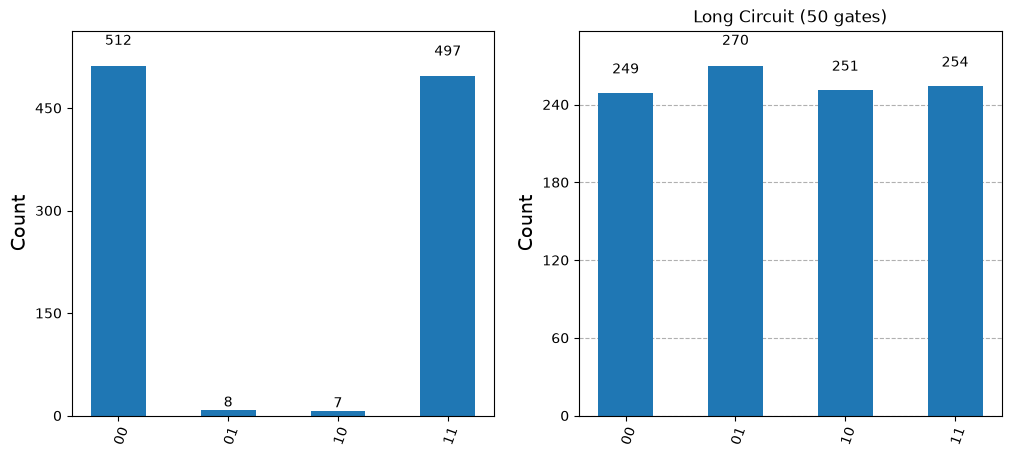

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_histogram(counts_noisy, ax=ax1, title="Short Circuit (50 ns gates)")
plot_histogram(counts_long, ax=ax2, title="Long Circuit (50 gates)")
plt.show()